<span style="color:olive; font-size:40px">**Differential Gene Expression (DGE)**</span>

⚠️  <span style="color: orange; font-size:18px">***Restart Kernel***</span>

<span style="font-size:16px; font-weight:bold"> In this notebook, data will be normalized, integrated, and clustered. </span> 

<span style="font-size:14px; color:red; font-weight:bold"> <strong>Note:</strong> All newly created notebooks must include an initial cell for environment setup and memory usage management. </span>

<span style="color:olive; font-size:16px">**Import libraries**</span>

In [8]:
import scanpy as sc
import decoupler as dc
import gc
import pandas as pd
import anndata as ad
import psutil, gc, os, zipfile
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf as pdf_backend
import seaborn as sns
from pathlib import Path
import numpy as np
from scipy import stats

In [10]:

sc.settings.n_jobs     = 4                  # Use multiple CPU cores for parallel processing (if supported by the function)
sc.settings.verbosity  = 2              # Set verbosity level (0 = errors only, 1 = warnings, 2 = info, 3 = debug)  
sc.settings.figdir     = '../results/'    # Directory to save figures
np.random.seed(42) 

raw_dir  = Path('../data/Raw_matrix')
ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)


def check_ram():
    ram = psutil.Process().memory_info().rss / 1e9
    print(f"RAM in use: {ram:.1f} GB")
    if ram > 11:
        print("⚠️ High RAM — consider restarting kernel soon")

def find_matrix_folder(patient_dir):
    for subfolder in patient_dir.iterdir():
        if subfolder.is_dir() and any(subfolder.rglob('*.mtx*')):
            return subfolder
    return None

check_ram()

RAM in use: 0.4 GB


<span style="color:olive; font-size:22px">**Define Functions**</span>

   - <span style="color:olive; font-size:16px">**Pseudobulk Aggregation**</span>: <span style="font-size:14px;">This function aggregates raw counts into a pseudobulk AnnData object, which is essential for performing differential gene expression analysis at the sample level (e.g., patient level) rather than at the single-cell level.</span>

In [6]:
def get_pseudobulk_matrix(adata, sample_col='patient_id', group_col='cell_type'):
    """
    Aggregates raw counts into a pseudobulk AnnData object and filters low-quality samples.
    """
    print(f"Aggregating {group_col} by {sample_col}...")
    
    # 1. Aggregation (Sum of raw counts)
    pbulk = dc.pp.pseudobulk(
        adata,
        sample_col=sample_col,
        groups_col=group_col,
        layer='raw_counts', # Using raw counts
        mode='sum'
    )
    
    # 2. Sample filtering (Quality Control)
    # The manual recommends at least 10 cells and 1000 counts per pseudobulk sample to ensure reliable estimates.
    dc.pp.filter_samples(pbulk,
                         min_cells=20,
                         min_counts=1000)
    
    # Clear internal scanpy/anndata noise
    pbulk.X = pbulk.X.astype(float)
    
    return pbulk


In [ ]:
def explore_variability(pbulk):
    """
    Normalizes and computes PCA to visualize condition separation.
    """
    # Save raw counts in a layer before normalization
    pbulk.layers["counts"] = pbulk.X.copy()
    
    # Standard preprocessing for visualization
    sc.pp.normalize_total(pbulk, target_sum=1e4)
    sc.pp.log1p(pbulk)
    sc.pp.scale(pbulk, max_value=10)
    sc.tl.pca(pbulk)
    
    # Restore raw counts to .X (necessary for downstream statistical tests)
    dc.pp.swap_layer(pbulk, key="counts", inplace=True)
    
    # PCA visualization
    sc.pl.pca(pbulk, color=["condition", "patient_id"],
              size=300,                                 # Increase point size for better visibility
              alpha=0.7,                                # Add some transparency to points
              frameon=True)
    
    return pbulk


   - <span style="color:olive; font-size:16px">**Cell-Type Specific DEG Analysis**</span>: <span style="font-size:14px;">This function performs differential gene expression analysis for a specific cell type between two conditions (e.g., Control vs Treated) using the pseudobulk data. It uses the **Wilcoxon rank-sum test** to identify significantly differentially expressed genes and applies multiple testing correction to control the false discovery rate.</span>

In [4]:
def run_comparison(pbulk_obj, target_cell_type, condition_col='condition', reference='ND'):
    """
    Performs DEG for a specific cell type at the pseudobulk level.
    """
    # Extract the target cell type's pseudobulk data
    subset = pbulk_obj[pbulk_obj.obs['cell_type'] == target_cell_type].copy()  # Create a copy to avoid modifying the original object
    
    # Normalize the aggregated counts (Internal Log-Norm for Wilcoxon)
    sc.pp.normalize_total(subset, target_sum=1e6)
    sc.pp.log1p(subset)
    
    # Run DEG
    sc.tl.rank_genes_groups(
        subset, 
        groupby=condition_col, 
        reference=reference,                # The reference condition is the Newly Diagnosed (ND) group
        method='wilcoxon',
        pts=True                            # Percentage of cells expressing the gene
    )
    
    return subset

   - <span style="color:olive; font-size:16px">**DEG table extraction**</span>: <span style="font-size:14px;">This function extracts the DEG results into a structured table format for downstream analysis and visualization.</span>

In [5]:
def extract_deg_table(analyzed_subset, target_group='Rec'):
    """
    Extracts a clean DataFrame from the results.
    """
    DEG_df = sc.get.rank_genes_groups_df(analyzed_subset, group=target_group)        #Compare Rec vs ND
    # Add cell type info for master tables
    DEG_df['cell_type'] = analyzed_subset.obs['cell_type'].unique()[0]          
    return DEG_df

   - <span style="color:olive; font-size:16px">**Visualization through Volcano Plots**</span>: <span style="font-size:14px;">This function generates volcano plots for visualizing the differential gene expression results. It highlights genes that pass specified log2 fold change and adjusted p-value thresholds, making it easier to identify significant DEGs.</span>

In [6]:
def plot_deg_volcano(deg_df, cell_type, logfc_thresh=1.0, adj_pval_thresh=0.05):
    """
    Generates a volcano plot for a specific cell type's DEG results.
    Highlights genes passing log2FC and Adjusted P-value thresholds.
    """
    print(f"Generating Volcano Plot for: {cell_type}")
    
    # We use decoupler's optimized volcano plotter
    # It automatically handles the -log10 transformation of p-values
    dc.plot_volcano_df(
        deg_df, 
        x='logfoldchanges', 
        y='pvals_adj', 
        top=20,                 # We limit to top 20 to identify key DEGs of interest. 
        sign_thr=adj_pval_thresh, 
        lFC_thr=logfc_thresh,
        title=f"DEG: {cell_type} (Recurrent vs Newly Diagnosed)"
    )
    
    # Save the figure to your results directory
    plt.savefig(ckpt_dir / f"Volcano_{cell_type}.pdf", bbox_inches='tight')
    plt.close()

<span style="color:olive; font-size:22px">**Variability Exploration**</span>

Aggregating cell_type by patient_id...
normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)


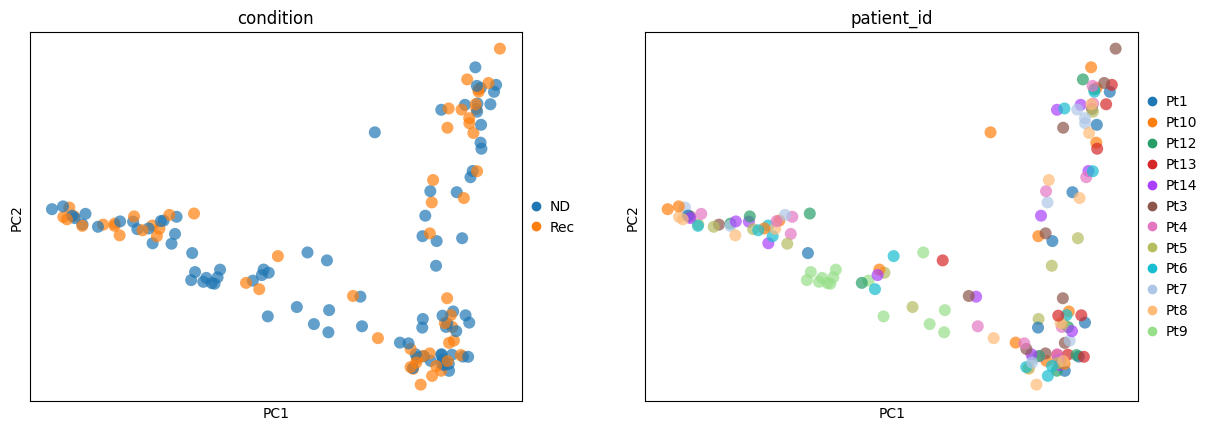

In [33]:
# 1. Load data
adata = sc.read_h5ad(ckpt_dir / 'part5_annotated_adata.h5ad')

# 2. Generate Pseudobulk (This object is much smaller than single-cell)
pbulk = get_pseudobulk_matrix(adata)

# 3. CRITICAL: Free single-cell memory now
del adata
gc.collect()

# 4. Explore variability and visualize PCA
pbulk = explore_variability(pbulk)


<span style="color:red; font-size:25px">Ser explicit amb la variança de les components (el primer component PC1 es més explicatiu que el PC2 i per tant la variança d'aquest es diferent del PC2) i explicar el component de la perpendicularitat dels eixos en la PCA. 

<span style="color:olive; font-size:16px">**This PCA suggests that the main transcriptomic variability in the dataset is driven by cellular programs and inter-patient differences rather than a global separation between ND and Rec conditions. The absence of clusters completely segregated by condition indicates that changes associated with recurrence likely occur in a cell type-specific manner or tumor states, reinforcing the need to perform pseudobulk differential expression analysis stratified by cluster or cell type**</span>

In [66]:
pbulk.obs.sort_values(by='psbulk_cells').head()

,patient_id,cell_type,condition,patient,outlier,mt_outlier,predicted_doublet,psbulk_cells,psbulk_counts
Pt10_Activated_Endothelial,Pt10,Activated_Endothelial,ND,Pt10,False,False,False,20.0,43842.0
Pt10_Proliferative,Pt10,Proliferative,ND,Pt10,False,False,False,21.0,300419.0
Pt9_NK/Cytotoxic_T,Pt9,NK/Cytotoxic_T,ND,Pt9,False,False,False,22.0,48893.0
Pt6_Proliferative,Pt6,Proliferative,Rec,Pt6,False,False,False,22.0,359588.0
Pt3_Oligo_like,Pt3,Oligo_like,Rec,Pt3,False,False,False,22.0,390490.0


<span style="color:teal; font-size:16px">What does these PCs represent? What is the variance explained by each PC?</span>
Es important destacar que els components principals (PCs) representen les direccions de màxima variància en les dades. El primer component (PC1) explica la major part de la variància, mentre que el segon component (PC2) explica una quantitat menor. La perpendicularitat dels eixos en la PCA indica que els components són ortogonals entre si, el que significa que no estan correlacionats i representen diferents aspectes de la variabilitat en les dades.

Quin és el responsable de les diferències entre els grups? Quines són les característiques que defineixen cada grup? Aquestes preguntes es poden respondre mitjançant l'anàlisi de les càrregues dels components principals, que indiquen quines variables contribueixen més a cada component i, per tant, a les diferències observades entre els grups.

<span style="color:orange; font-size:16px">**Note:** To study the variance explained by each PC, we should ensure that there are enough samples in each group (e.g., ND and Recurrent) to perform the statistical test. The error was coming from <code>scipy.stats.f_oneway</code>. To compare if PC1 correlates with the condition, it needs at least 2 patients in ND and 2 in Recurrent. If in a small cluster there is only one patient represented, the mathematical test fails.</span> ANOVA test requires at least two samples in each group to compare the means.

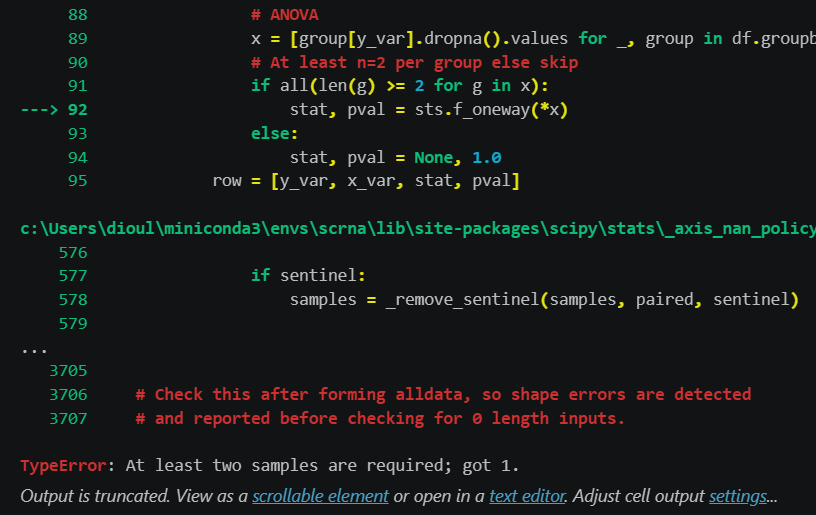

In [37]:
print(pbulk.obs.nunique())

patient_id            12
cell_type             16
condition              2
patient               12
outlier                1
mt_outlier             1
predicted_doublet      1
psbulk_cells         119
psbulk_counts        147
dtype: int64


Variables seleccionadas para el test: ['patient_id', 'cell_type', 'condition', 'patient', 'psbulk_cells']


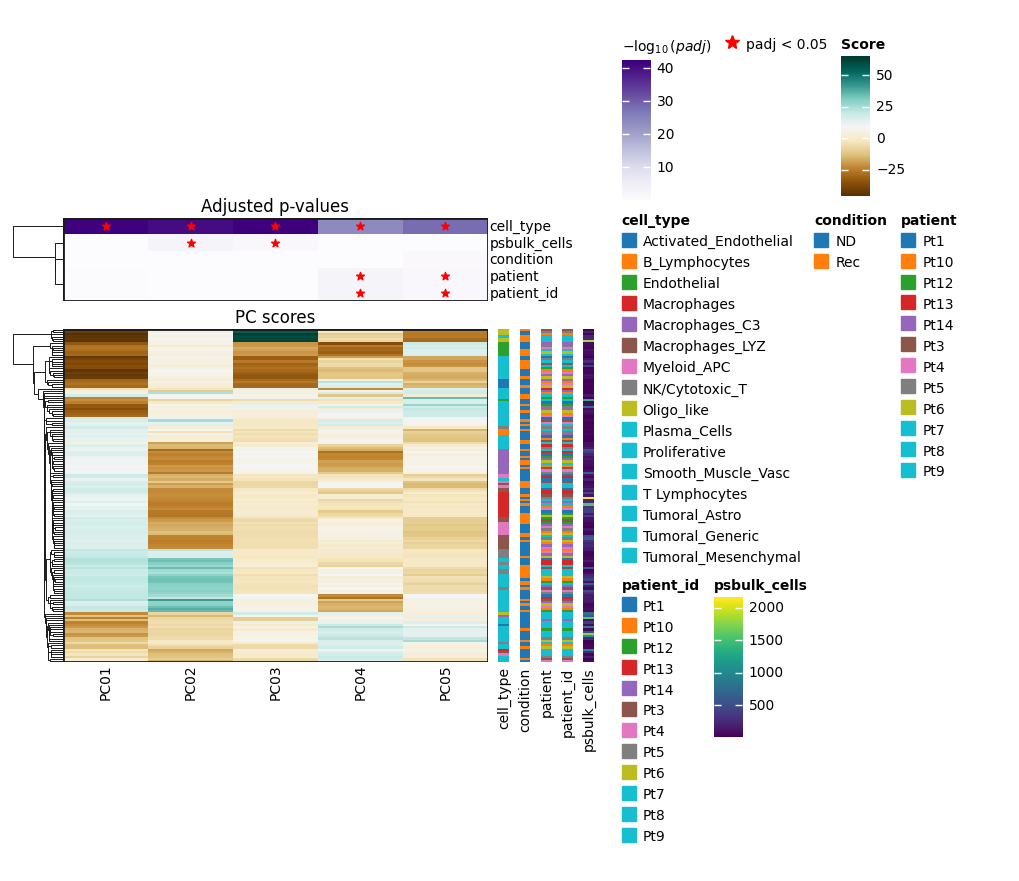

In [38]:
"""""
# 1. Definir qué columnas de metadatos nos interesan de verdad
# Evitamos columnas con IDs únicos o valores constantes que rompen el test
interesante_keys = ['condition', 'cell_type', 'patient_id']  # <--- Solo estas columnas tienen sentido biológico para comparar

# 2. Ejecutar el test solo en esas columnas
# Esto evita el error de "got 1 sample" al ignorar columnas irrelevantes
dc.tl.rankby_obsm(
    pbulk, 
    key="X_pca", 
    obs_keys=interesante_keys # <--- Forzamos solo las variables biológicas
)

# 3. Visualización (Asegúrate de que 'pbulk' tiene calculada la varianza)
sc.pl.pca_variance_ratio(pbulk, n_pcs=10) 

dc.pl.obsm(
    adata=pbulk, 
    nvar=5, # Solo tenemos 3 variables en interesting_keys
    titles=["PC scores", "Adjusted p-values"], 
    figsize=(10, 5)
)
"""""

# 1. Identificar qué columnas en pbulk.obs tienen al menos 2 valores únicos
# Esto descarta automáticamente las columnas con n=1 que causan el TypeError
variables_validas = [
    col for col in pbulk.obs.columns 
    if pbulk.obs[col].nunique() > 1
]

# 2. (Opcional) Filtrar columnas con demasiados valores únicos (como IDs de células o índices)
# Si una columna tiene tantos valores únicos como filas, tampoco es útil para ANOVA
variables_biologicas = [
    col for col in variables_validas 
    if pbulk.obs[col].nunique() < pbulk.n_obs
]

print(f"Variables seleccionadas para el test: {variables_biologicas}")

# 3. Ejecutar el test de decoupler con la lista segura
dc.tl.rankby_obsm(
    pbulk, 
    key="X_pca", 
    obs_keys=variables_biologicas
)

# 4. Visualización
# Asignar una paleta con muchos colores a la columna cell_type
#pbulk.uns['cell_type_colors'] = sc.pl.palettes.default_20
#pbulk.uns['patient_id_colors'] = sc.pl.palettes.default_102 # Paleta gigante si tienes muchos pacientes
dc.pl.obsm(pbulk, 
           nvar=len(variables_biologicas),
           titles=["PC scores", "Adjusted p-values"],
           figsize=(10, 5))


<span style="color:orange; font-size:16px">**Note:** On the analysis above, we can see that PC2 and PC3 are significantly associated with psbulk_cells. This information suggests that the major differences between the samples in those components are driven by the number of cells that were aggregated to create each pseudobulk sample and not by the biological condition (Newly Diagnosed (ND) vs Recurrent). <br><br>The problem is that if a recurrent patient contributed 2,000 macrophages and a ND patient only contributed 100, the PCA will see a massive difference. But that difference is technical (how many cells the sequencer captured), not biological.</span>

To adress this issue, we will filter genes based on their expression across samples by <code>dc.pp.filter_by_prop()</code> IT acts on the columns (genes). What it does: It looks at each gene one by one within a cell type and says: "If this gene is only detected in 2% of the Macrophage samples, I will remove the gene from my analysis". The goal is to eliminate genes that are statistical noise or that are expressed so erratically that they are not useful for comparing ND vs. Recurrent.</span>

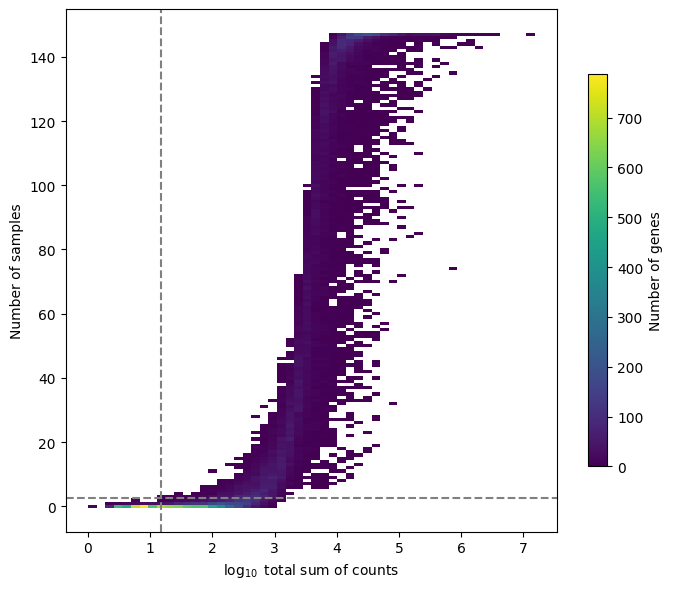

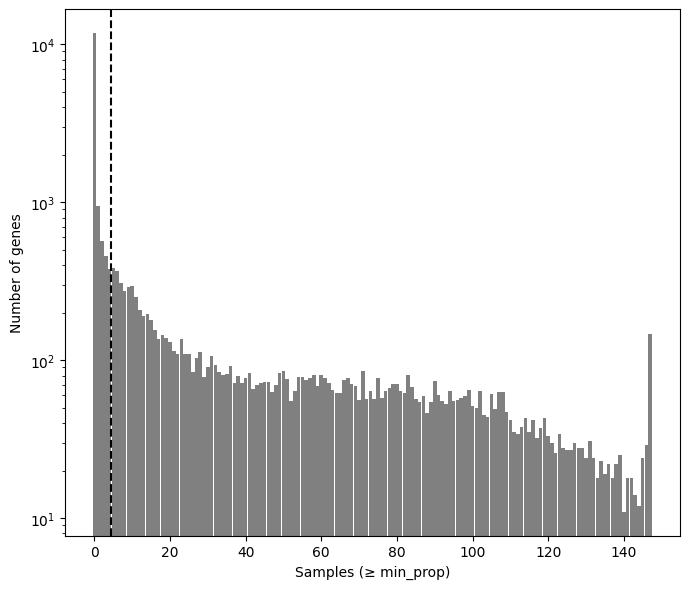

In [ ]:
dc.pl.filter_by_expr(
    adata=pbulk, 
    group="cell_type",
    min_count=10,                       # Minimum count of a gene in at least one group (cell type)
    min_total_count=15,                 # Minimum total count of a gene across all groups
    large_n=10,                         # Threshold for large number of cells
    min_prop=0.7,                       # Minimum proportion of cells expressing the gene in a group
    figsize=(7, 6)
)

# Visualización previa de filter_by_prop
# Puedes hacerlo sobre el objeto completo o sobre un tipo celular específico (ej. Macrófagos)
dc.pl.filter_by_prop(
    adata=pbulk, 
    min_prop=0.2,                   # Minimum proportion of samples expressing the gene (e.g., 20% of pseudobulk samples)
    min_smpls=5,                     # Minimum number of samples expressing the gene
    figsize=(7, 6)
)



In [ ]:
pbulk.n_vars

25355

In [52]:
# 2. Filter genes: count-based (edgeR logic)
dc.pp.filter_by_expr(
    adata=pbulk,
    group='cell_type',
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7
)
print(f"Genes after filter_by_expr: {pbulk.n_vars:,}")

# 3. Filter genes: proportion-based (dropout logic)
dc.pp.filter_by_prop(
    adata=pbulk,
    min_prop=0.2,
    min_smpls=5
)
print(f"Genes after filter_by_prop: {pbulk.n_vars:,}")

# 4. Save filtered pseudobulk checkpoint
pbulk.write_h5ad(ckpt_dir / 'pbulk_filtered.h5ad')
print("Pseudobulk matrix saved after filtering.")

Genes after filter_by_expr: 14,794
Genes after filter_by_prop: 11,218
Pseudobulk matrix saved after filtering.


   - <span style="color:salmon; font-size:16px">**Load the filtered bulk data**</span>

In [ ]:
pfil_bulk = sc.read_h5ad(ckpt_dir / 'pbulk_filtered.h5ad')

In [64]:
# Drop the 'patient' column since we already have 'patient_id'
pfil_bulk.obs = pfil_bulk.obs.drop(columns=["patient"])
print(pfil_bulk.obs.columns)

Index(['patient_id', 'cell_type', 'condition', 'outlier', 'mt_outlier',
       'predicted_doublet', 'psbulk_cells', 'psbulk_counts'],
      dtype='object')


<span style="color:salmon; font-size:14px">**Let's execute again the PC visualization **</span>

Variables seleccionadas para el test: ['patient_id', 'cell_type', 'condition', 'psbulk_cells']


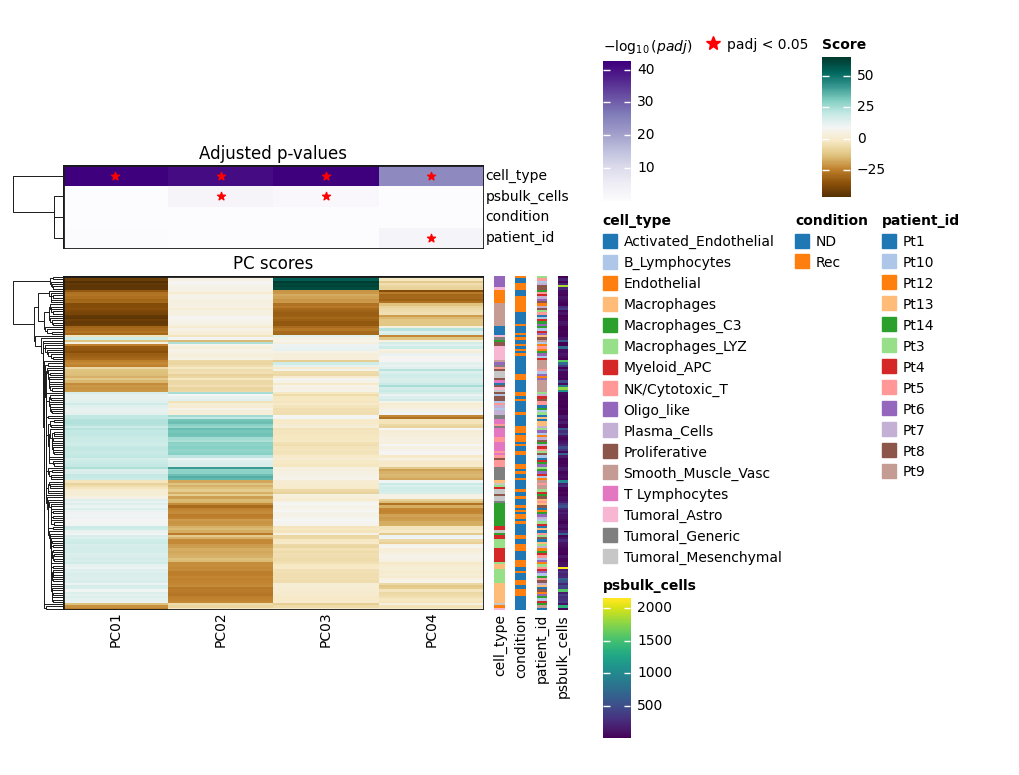

In [ ]:

#pfil_bulk = sc.read_h5ad(ckpt_dir / 'pbulk_filtered.h5ad')
# 1. Identificar qué columnas en pfil_bulk.obs tienen al menos 2 valores únicos
# Esto descarta automáticamente las columnas con n=1 que causan el TypeError
variables_validas = [
    col for col in pfil_bulk.obs.columns 
    if pfil_bulk.obs[col].nunique() > 1
]

# 2. (Opcional) Filtrar columnas con demasiados valores únicos (como IDs de células o índices)
# Si una columna tiene tantos valores únicos como filas, tampoco es útil para ANOVA
variables_biologicas = [
    col for col in variables_validas 
    if pfil_bulk.obs[col].nunique() < pfil_bulk.n_obs
]

print(f"Variables seleccionadas para el test: {variables_biologicas}")

# 3. Ejecutar el test de decoupler con la lista segura
dc.tl.rankby_obsm(
    pfil_bulk, 
    key="X_pca", 
    obs_keys=variables_biologicas
)

# 4. Visualización
# Asignar una paleta con muchos colores a la columna cell_type
#pfil_bulk.uns['cell_type_colors'] = sc.pl.palettes.default_20
#pfil_bulk.uns['patient_id_colors'] = sc.pl.palettes.default_102 # Paleta gigante si tienes muchos pacientes

cmap_obs = {
    "cell_type": 'tab20',
    "patient_id": 'tab20b',
}

dc.pl.obsm(pfil_bulk, 
           nvar=len(variables_biologicas),
           titles=["PC scores", "Adjusted p-values"],
           figsize=(10, 5),
           cmap_obs=cmap_obs)


<span style="color:orange; font-size:14px">Observing the PC scores and adjusted p-values after filtering genes based on their expression across samples, we can see that the association of PC2 and PC3 with psbulk_cells still persists.This suggests that the technical variation related to the number of cells aggregated in each pseudobulk sample is still influencing the PCA results, even after filtering out genes that are not consistently expressed across samples.</span> 

<span style="font-size:14px">**For this reason, we have to change our question. Instead of asking:**

   - <span style="font-size:14px"> *Is condition associated with the whole dataset?*</span>

We ask:
   - <span style="font-size:16px; color:salmon">**Within this cell type, does condition still matter?**</span>

<span style="color:purple; font-size:22px">**TO BE CONTINUED**</span>